# Implementation of proper graph coloring algorithm with CFTP & Bounding chain

In [23]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Requierements for the algorithm :
We must have that $\Delta = \max\{d(u,v)\, \forall u, v\in V\} < |C|$ where $C$ is the set of colors in order for the bounding chains algorithm to start and not got traped in the initial state.

We follow the usual path of simulating with the CFTP algorithm. For the proper graph coloring sampling we use the following transition kernel.

Let $n$ be our timestep in the CFTP algorithm and $v$ be a random node of the graph drawn from $\text{Unif}(V)$. We set $y_n(v)\leftarrow\emptyset$. Then we draw a random color $c\sim\text{Unif}(C)$. If there is no $w\in N(v)$ such that $y_n(w)=\{c\}$ then $y_n(v)\leftarrow y_n(v)\cup\{c\}$. We repeat this process of color drawing until $c\notin \cup_{w\in N(v)}y_n(w)$ or $|y_n(v)|>\Delta$.

The check for coalescence at time $T=0$ of the bounding chain is done by verifying if $|y_0(v)|=1$ $\forall v\in V$.

Since the loop of drawing colors can be very long and has not a fixed length, it can be hard to design a great way of stocking the random variables in order to always use the same for a fixed timestep. We use a trick to overcome this difficulty : for each timestep $n$ and each iteration $i$ of the color drawing, we change the seed of random generation using the timestep and the iteration number themselves. This way, at fixed $n$ and $i$ the drawn color (and previously the drawn node) is always the same without the need to store them.

In [24]:
def CFTP_color_graph(G, colors):
    # Check that the number of colors is bigger than the maximum degree of the graph
    if len(colors) <= max(dict(G.degree()).values()):
        print("The number of colors must be greater than the maximum degree of the graph.")
        return None, np.nan
    max_degree = max(dict(G.degree()).values())
    t = -1
    while True:
        if t < -2**19: # Set a maximum time limit to prevent infinite loops
            print("Failed to find a proper coloring within the given time limit.")
            return None, np.nan
        y = [colors for _ in G.nodes()] # Initialize the coloring of the graph with all colors for each node
        for n in range(t, 1): # number of iterations to run the chains in the past to the present t=0
            np.random.seed(-n)
            random_node = np.random.choice(list(G.nodes()))
            y[random_node] = []
            i_while_true = 0
            while True:
                np.random.seed(i_while_true-n) 
                random_color = np.random.choice(colors)
                # Check if the random color is valid for the random node
                if all([random_color] != y[neighbor] for neighbor in G.neighbors(random_node)):
                    y[random_node].append(random_color)
                colors_of_neighbors = [y[neighbor] for neighbor in G.neighbors(random_node)]
                colors_of_neighbors = [color for sublist in colors_of_neighbors for color in sublist]
                if (random_color not in colors_of_neighbors or len(y[random_node])>max_degree):
                    break
                else:
                    i_while_true += 1
        # Check if the coloring is proper
        if all(len(y[node]) == 1 for node in G.nodes()):
            return {node: y[node][0] for node in G.nodes()}, t
        else:
            t *= 2

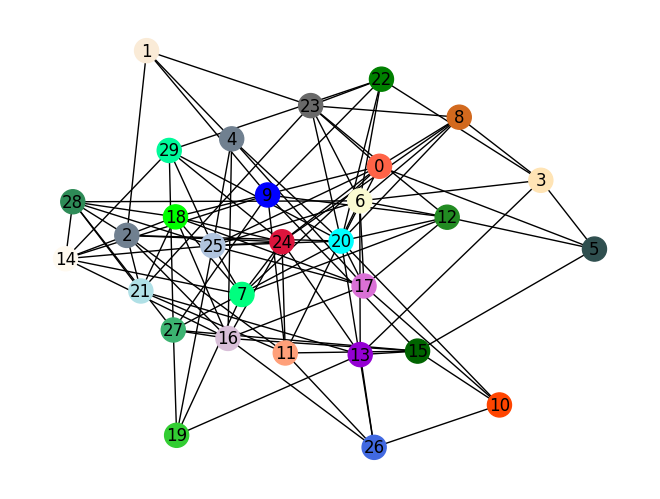

In [25]:
G = nx.erdos_renyi_graph(30, 0.3)
colors = list(mcolors.cnames.keys())

new_coloring, _ = CFTP_color_graph(G, colors)
# Draw the graph with the assigned colors
color_map = {node: new_coloring[node] for node in G.nodes()}
plt.figure(1)
nx.draw(G, with_labels=True, node_color=[color_map[node] for node in G.nodes()])
plt.show()

# check if the coloring is proper by checking that no two adjacent nodes have the same color
for node in G.nodes():
    for neighbor in G.neighbors(node):
        assert new_coloring[node] != new_coloring[neighbor], "The coloring is not proper."

In [26]:
conv_time_lst = []
theo_conv_time_lst = []
graph_size = np.linspace(2, 31, 30)
proba_node = np.linspace(0.1, 0.9, 9)
colors = list(mcolors.cnames.keys())
k = len(colors)
for g in graph_size:
    for p in proba_node:
        G = nx.erdos_renyi_graph(int(g), p)
        max_degree_of_G = max(dict(G.degree()).values())
        beta = 1-(1-(max_degree_of_G*(max_degree_of_G+1)/(k-max_degree_of_G+1)))/g
        if k>=max_degree_of_G*(max_degree_of_G+2):
            theo_conv_time = np.log(g)/np.log(beta)
            theo_conv_time_lst.append((graph_size, proba_node, theo_conv_time))
        else:
            theo_conv_time_lst.append((graph_size, proba_node, np.nan))
        new_coloring, conv_time = CFTP_color_graph(G, colors)
        if new_coloring is None:
            pass
        else:
            for node in G.nodes():
                for neighbor in G.neighbors(node):
                    assert new_coloring[node] != new_coloring[neighbor], "The coloring is not proper."
        conv_time_lst.append((graph_size, proba_node, conv_time))

<Figure size 640x480 with 0 Axes>

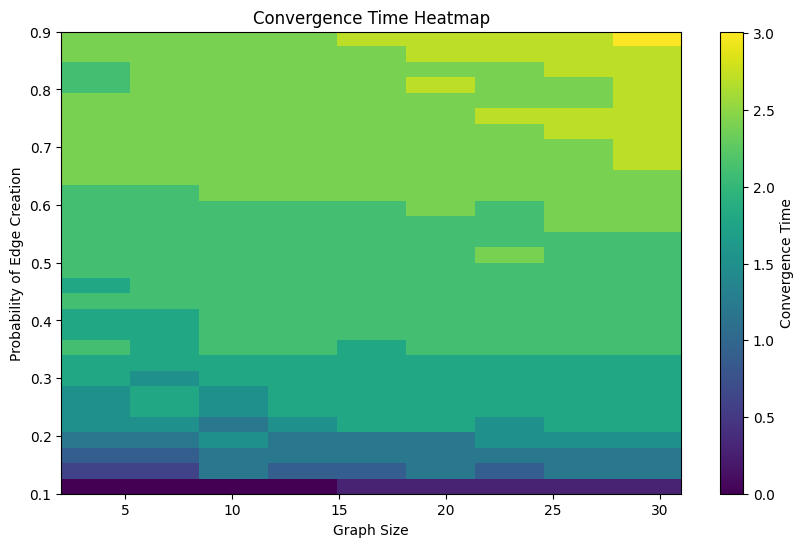

<Figure size 640x480 with 0 Axes>

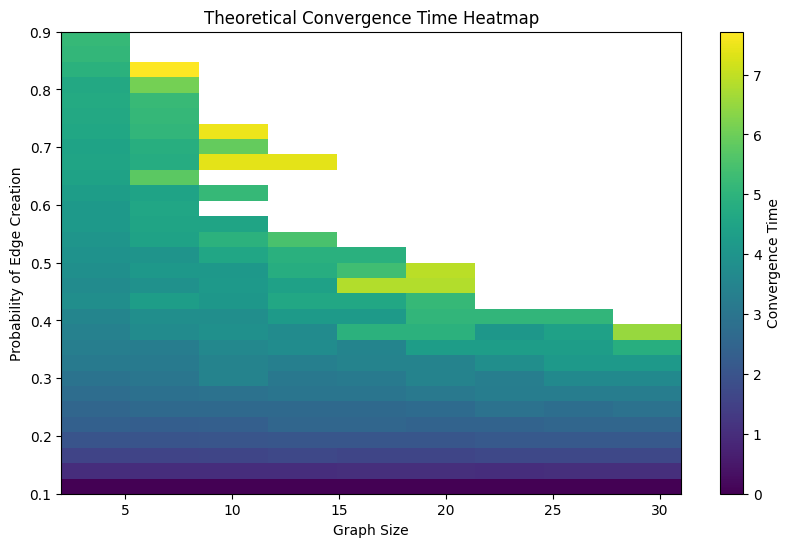

In [27]:
plt.figure(0)
conv_time_matrix = np.array([conv_time_lst[i][2] for i in range(len(conv_time_lst))]).reshape(len(graph_size), len(proba_node))
plt.figure(figsize=(10, 6))
plt.imshow(np.log10(np.abs(conv_time_matrix)), aspect='auto', origin='lower', extent=[graph_size.min(), graph_size.max(), proba_node.min(), proba_node.max()])
plt.colorbar(label='Convergence Time')
plt.xlabel('Graph Size')
plt.ylabel('Probability of Edge Creation')
plt.title('Convergence Time Heatmap')
plt.show()

plt.figure(1)
theo_conv_time_matrix = np.array([theo_conv_time_lst[i][2] for i in range(len(theo_conv_time_lst))]).reshape(len(graph_size), len(proba_node))
plt.figure(figsize=(10, 6))
plt.imshow(np.log(np.abs(theo_conv_time_matrix)), aspect='auto', origin='lower', extent=[graph_size.min(), graph_size.max(), proba_node.min(), proba_node.max()])
plt.colorbar(label='Convergence Time')
plt.xlabel('Graph Size')
plt.ylabel('Probability of Edge Creation')
plt.title('Theoretical Convergence Time Heatmap')
plt.show()